# Smart MCQ Solver Challenge
### DL & GenAI Project | IIT Madras BS in Data Science
**Student:** Raghav Kapoor | **Roll No:** 23f2002364 | **Term:** T2-2026

## Problem Statement
Given an MCQ with 5 options (A to E), predict the top 3 most probable correct answers ranked by confidence.  
Evaluated using **MAP@3** (Mean Average Precision at 3).

## Notebook Structure
1. Setup & Imports
2. EDA & Data Exploration  
3. Classical ML Baseline
4. MLP from Scratch (PyTorch)
5. Fine-tuned Transformer (DeBERTa)
6. LLM Zero-shot Ranker
7. Final Inference & Submission


## Installs


In [1]:
!pip install wandb -q
!pip install sentence-transformers -q
!pip install transformers datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.5 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

## Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from kaggle_secrets import UserSecretsClient
import warnings
warnings.filterwarnings('ignore')

print("imports done")
print(f"torch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

imports done
torch version: 2.10.0+cu128
GPU available: True


## WandB Setup

In [6]:
# using kaggle secrets to avoid exposing the api key
secrets = UserSecretsClient()
wandb_key = secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_key)
print("wandb login successful")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


wandb login successful


## Data Loading

In [8]:
DATA_PATH = '/kaggle/input/competitions/smart-mcq-solver-challenge/'

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns: {train.columns.tolist()}")
print(f"Test columns: {test.columns.tolist()}")

Train shape: (2000, 8)
Test shape: (500, 7)

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


## Exploratory Data Analysis

Basic look of the training data

In [9]:
print("=== Sample Questions ===\n")
for i in range(3):
    print(f"Q{i+1}: {train['prompt'].iloc[i][:200]}")
    for col in ['A','B','C','D','E']:
        marker = "✓" if train['answer'].iloc[i] == col else " "
        print(f"  [{marker}] {col}: {train[col].iloc[i][:100]}")
    print()

=== Sample Questions ===

Q1: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
  [ ] A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not ha
  [✓] B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relation
  [ ] C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consci
  [ ] D: Martin Heidegger believes that the relationship between time and human existence is cyclical. The pa
  [ ] E: Martin Heidegger believes that time is an illusion, and the past, present, and future are all happen

Q2: What is accelerator-based light-ion fusion?
  [✓] A: Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particl
  [ ] B: Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particl
  [ ] C:

Answer distribution

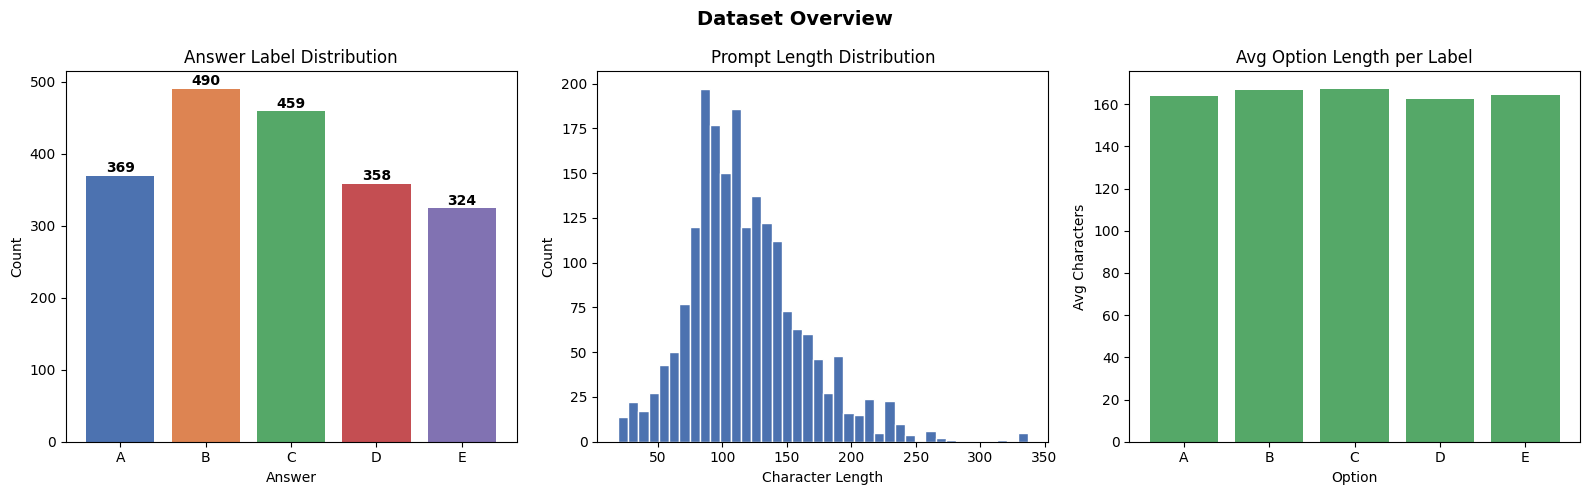

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# answer distribution
answer_counts = train['answer'].value_counts().sort_index()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
axes[0].bar(answer_counts.index, answer_counts.values, color=colors)
axes[0].set_title('Answer Label Distribution')
axes[0].set_xlabel('Answer')
axes[0].set_ylabel('Count')
for i, v in enumerate(answer_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# prompt length
train['prompt_len'] = train['prompt'].apply(len)
axes[1].hist(train['prompt_len'], bins=40, color='#4C72B0', edgecolor='white')
axes[1].set_title('Prompt Length Distribution')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Count')

# avg option length
for col in ['A','B','C','D','E']:
    train[f'{col}_len'] = train[col].apply(len)
avg_lens = [train[f'{col}_len'].mean() for col in ['A','B','C','D','E']]
axes[2].bar(['A','B','C','D','E'], avg_lens, color='#55A868')
axes[2].set_title('Avg Option Length per Label')
axes[2].set_xlabel('Option')
axes[2].set_ylabel('Avg Characters')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
train['correct_len'] = train.apply(lambda row: len(row[row['answer']]), axis=1)
wrong_lens = []
for _, row in train.iterrows():
    wrong = [len(row[col]) for col in ['A','B','C','D','E'] if col != row['answer']]
    wrong_lens.append(np.mean(wrong))
train['wrong_avg_len'] = wrong_lens

print("Avg length of CORRECT options:", round(train['correct_len'].mean(), 1))
print("Avg length of WRONG options:  ", round(train['wrong_avg_len'].mean(), 1))
print()
print("Answer distribution (%):")
print((train['answer'].value_counts(normalize=True)*100).round(2))
print()
print("Missing values in train:", train.isnull().sum().sum())
print("Missing values in test: ", test.isnull().sum().sum())

Avg length of CORRECT options: 181.9
Avg length of WRONG options:   160.7

Answer distribution (%):
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

Missing values in train: 0
Missing values in test:  0


### EDA Observations
- 2000 training samples, 500 test samples
- Answer distribution is mildly imbalanced — B is most frequent (24.5%), E least (16.2%)
- Correct and wrong options have similar average lengths, so length is not a useful signal
- Prompt lengths vary widely suggesting diverse question types and domains
- No missing values in either train or test

## MAP@3 Helper + Dummy Baseline

In [14]:
# MAP@3 utility — we'll reuse this throughout the notebook
def mapk(actual, predicted, k=3):
    """
    actual: list of true labels e.g. ['A', 'B', 'C', ...]
    predicted: list of ranked predictions e.g. [['A','B','C'], ['C','A','D'], ...]
    """
    score = 0.0
    for a, p in zip(actual, predicted):
        if a in p[:k]:
            score += 1.0 / (p[:k].index(a) + 1)
    return score / len(actual)

# dummy baseline — always predict A B C
dummy_preds = [['A','B','C']] * len(train)
actual = train['answer'].tolist()
dummy_map3 = mapk(actual, dummy_preds)
print(f"Dummy Baseline MAP@3: {dummy_map3:.4f}")

# log to wandb
run = wandb.init(
    project="23f2002364-t22026",
    entity="23f2002364-iit-madras",
    name="baseline-dummy",
    config={"model": "dummy", "strategy": "always_predict_ABC"}
)
wandb.log({"map@3": dummy_map3})
wandb.finish()
print("logged to wandb")

Dummy Baseline MAP@3: 0.3835


map@3,▁
map@3,0.3835


logged to wandb


In [15]:
submission = pd.DataFrame({
    'ID': test['id'],
    'Prediction': 'A B C'
})
submission.to_csv('submission_dummy.csv', index=False)
print("Dummy submission saved")
submission.head()

Dummy submission saved


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C
